In [84]:
# --- Imports & API Setup ---
import pandas as pd
import numpy as np
import requests
import json
import time
import random
import matplotlib.pyplot as plt
import simfin as sf
from simfin.names import *
from datetime import datetime, timedelta

# SimFin API
sf.set_api_key("4e0d0ff7-a1af-4333-9f4b-55d97e801b35")
sf.set_data_dir("~/simfin_data/")

# SEC EDGAR API
SEC_HEADERS = {"User-Agent": "ProjectHighbourne research@example.com"}

print("Imports loaded. SimFin & SEC EDGAR APIs ready.")

Imports loaded. SimFin & SEC EDGAR APIs ready.


In [85]:
# --- Load Russell 3000 Tickers from CSV (excluding Energy sector) ---
df_tickers = pd.read_csv("Tickers.csv")
df_tickers = df_tickers[df_tickers["Sector"] != "Energy"]
Tickers = df_tickers["Ticker"].dropna().astype(str).str.strip().tolist()

print(f"Loaded {len(Tickers)} tickers (Energy excluded)")
print(Tickers[:20])

Loaded 2437 tickers (Energy excluded)
['HYLN', 'CATX', 'DC', 'NG', 'IE', 'CMT', 'CMCL', 'IDR', 'BHB', 'TMP', 'PRK', 'NHC', 'SEB', 'JELD', 'NXDR', 'OPTU', 'RC', 'BLND', 'ZIP', 'DDD']


In [86]:
# --- Load Price Data from SimFin ---

# Daily share prices
df_prices = sf.load_shareprices(market="us", variant="daily")

# Filter to Russell 3000 tickers
available = df_prices.index.get_level_values("Ticker").unique()
Tickers_matched = [t for t in Tickers if t in available]
Tickers_missing = [t for t in Tickers if t not in available]

df_prices = df_prices.loc[df_prices.index.get_level_values("Ticker").isin(Tickers_matched)]

print(f"Matched {len(Tickers_matched)}/{len(Tickers)} tickers in SimFin")
print(f"Missing: {len(Tickers_missing)} tickers")
if Tickers_missing:
    print(f"Sample missing: {Tickers_missing[:10]}")
print(f"\nPrices: {df_prices.shape}")

Dataset "us-shareprices-daily" on disk (1 days old).
- Loading from disk ... 

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/simfin/load.py:154: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(path, sep=';', header=0,


Done!
Matched 2227/2437 tickers in SimFin
Missing: 210 tickers
Sample missing: ['NXDR', 'OPTU', 'ACH', 'NXDT', 'MPT', 'AHRT', 'DCH', 'UAA', 'TE', 'TDAY']

Prices: (2646627, 9)


In [87]:
# --- Compute Market Cap (5 Year Lookback) ---

cutoff = (datetime.now() - timedelta(days=5*365)).strftime("%Y-%m-%d")

# Filter prices to last 5 years
prices = df_prices[df_prices.index.get_level_values("Date") >= cutoff].copy()

# Market Cap = Close * Shares Outstanding
mktcap = (prices["Close"] * prices["Shares Outstanding"]).unstack("Ticker")

print(f"Market Cap computed for {mktcap.shape[1]} tickers over {mktcap.shape[0]} trading days")
print(f"Date range: {mktcap.index.min()} to {mktcap.index.max()}")

Market Cap computed for 2227 tickers over 1007 trading days
Date range: 2021-04-05 00:00:00 to 2025-04-04 00:00:00


In [88]:
# --- Fetch All Financial Data from SEC EDGAR ---
import importlib
import edgar_utils
importlib.reload(edgar_utils)
from edgar_utils import load_cik_lookup, fetch_concept, cache_to_unstacked, build_daily_instant, build_daily_ttm

cik_lookup = load_cik_lookup()

# Instant concepts (balance sheet)
edgar_equity = fetch_concept(Tickers_matched, "StockholdersEquity", "edgar_equity_cache.json", cik_lookup, "instant")
edgar_debt = fetch_concept(Tickers_matched, "LongTermDebt", "edgar_debt_cache.json", cik_lookup, "instant")
edgar_cash = fetch_concept(Tickers_matched, "CashAndCashEquivalentsAtCarryingValue", "edgar_cash_cache.json", cik_lookup, "instant")

# Duration concepts (income statement) — these are quarterly values
edgar_revenue = fetch_concept(Tickers_matched, "Revenues", "edgar_revenue_cache.json", cik_lookup, "duration")
edgar_net_income = fetch_concept(Tickers_matched, "NetIncomeLoss", "edgar_netincome_cache.json", cik_lookup, "duration")
edgar_op_income = fetch_concept(Tickers_matched, "OperatingIncomeLoss", "edgar_opincome_cache.json", cik_lookup, "duration")
edgar_dna = fetch_concept(Tickers_matched, "DepreciationDepletionAndAmortization", "edgar_dna_cache.json", cik_lookup, "duration")

print("All EDGAR concepts fetched.")

[StockholdersEquity] Total: 2227 | Cached: 2226 | No CIK: 1 | To fetch: 0
  Result: 2172/2227 tickers with data

[LongTermDebt] Total: 2227 | Cached: 2226 | No CIK: 1 | To fetch: 0
  Result: 1665/2227 tickers with data

[CashAndCashEquivalentsAtCarryingValue] Total: 2227 | Cached: 2226 | No CIK: 1 | To fetch: 0
  Result: 2140/2227 tickers with data

[Revenues] Total: 2227 | Cached: 2226 | No CIK: 1 | To fetch: 0
  Result: 1399/2227 tickers with data

[NetIncomeLoss] Total: 2227 | Cached: 2226 | No CIK: 1 | To fetch: 0
  Result: 2173/2227 tickers with data

[OperatingIncomeLoss] Total: 2227 | Cached: 2226 | No CIK: 1 | To fetch: 0
  Result: 1787/2227 tickers with data

[DepreciationDepletionAndAmortization] Total: 2227 | Cached: 2226 | No CIK: 1 | To fetch: 0
  Result: 1459/2227 tickers with data

All EDGAR concepts fetched.


In [89]:
# --- Compute Valuation Ratios ---
trading_dates = mktcap.index

def trim_to_recent_good(daily_df):
    """
    For balance sheet (instant) data only.
    For each ticker, find the last date where data is bad (NaN or <= 0).
    Mask everything at/before that date so we only keep the most recent
    contiguous run of good data.
    """
    bad_mask = daily_df.isna() | (daily_df <= 0)
    last_bad = bad_mask.apply(lambda col: col[col].index.max() if col.any() else pd.NaT)
    trimmed = daily_df.copy()
    for t in trimmed.columns:
        if pd.notna(last_bad[t]):
            trimmed.loc[:last_bad[t], t] = np.nan
    return trimmed

# === Price-to-Book ===
eq_unstacked = cache_to_unstacked(edgar_equity)
equity_daily = build_daily_instant(eq_unstacked, trading_dates)
equity_daily = trim_to_recent_good(equity_daily)  # negative equity = bad
common_pb = mktcap.columns.intersection(equity_daily.columns)
pb_df = (mktcap[common_pb] / equity_daily[common_pb]).replace([np.inf, -np.inf], np.nan)

# === Price-to-Sales (TTM) ===
rev_unstacked = cache_to_unstacked(edgar_revenue)
revenue_ttm = build_daily_ttm(rev_unstacked, trading_dates)
revenue_ttm = revenue_ttm.where(revenue_ttm > 0)
common_ps = mktcap.columns.intersection(revenue_ttm.columns)
ps_df = (mktcap[common_ps] / revenue_ttm[common_ps]).replace([np.inf, -np.inf], np.nan)

# === Price-to-Earnings (TTM) ===
ni_unstacked = cache_to_unstacked(edgar_net_income)
net_income_ttm = build_daily_ttm(ni_unstacked, trading_dates)
net_income_ttm = net_income_ttm.where(net_income_ttm > 0)
common_pe = mktcap.columns.intersection(net_income_ttm.columns)
pe_df = (mktcap[common_pe] / net_income_ttm[common_pe]).replace([np.inf, -np.inf], np.nan)

# === EV/EBITDA (TTM) ===
# EV = Market Cap + Debt - Cash
# Fallback: if no cash, use MktCap + Debt. If no debt either, use MktCap.
debt_unstacked = cache_to_unstacked(edgar_debt)
cash_unstacked = cache_to_unstacked(edgar_cash)
debt_daily = build_daily_instant(debt_unstacked, trading_dates)
cash_daily = build_daily_instant(cash_unstacked, trading_dates)

# Start with market cap for all tickers that have EBITDA data
oi_unstacked = cache_to_unstacked(edgar_op_income)
dna_unstacked = cache_to_unstacked(edgar_dna)
common_ebitda = oi_unstacked.columns.intersection(dna_unstacked.columns)
ebitda_quarterly = oi_unstacked[common_ebitda] + dna_unstacked[common_ebitda].fillna(0)
ebitda_ttm = build_daily_ttm(ebitda_quarterly, trading_dates)
ebitda_ttm = ebitda_ttm.where(ebitda_ttm > 0)

# Build EV with graceful fallback
ev_tickers = mktcap.columns.intersection(ebitda_ttm.columns)
ev_df = mktcap[ev_tickers].copy()

# Add debt where available
debt_overlap = ev_tickers.intersection(debt_daily.columns)
ev_df[debt_overlap] = ev_df[debt_overlap] + debt_daily[debt_overlap].fillna(0)

# Subtract cash where available
cash_overlap = ev_tickers.intersection(cash_daily.columns)
ev_df[cash_overlap] = ev_df[cash_overlap] - cash_daily[cash_overlap].fillna(0)

ev_ebitda_df = (ev_df / ebitda_ttm[ev_tickers]).replace([np.inf, -np.inf], np.nan)

# === Summary ===
for name, df in [("P/B", pb_df), ("P/S", ps_df), ("P/E", pe_df), ("EV/EBITDA", ev_ebitda_df)]:
    cov = df.notna().sum() / df.shape[0] * 100
    good = (cov >= 90).sum()
    print(f"{name:12s}: {df.shape[1]} tickers | {df.count().sum():>8,} non-null | {good} good (>=90%)")

P/B         : 2172 tickers | 1,912,731 non-null | 1777 good (>=90%)
P/S         : 1330 tickers | 1,227,827 non-null | 1170 good (>=90%)
P/E         : 2164 tickers | 1,499,020 non-null | 1149 good (>=90%)
EV/EBITDA   : 1286 tickers |  917,272 non-null | 757 good (>=90%)


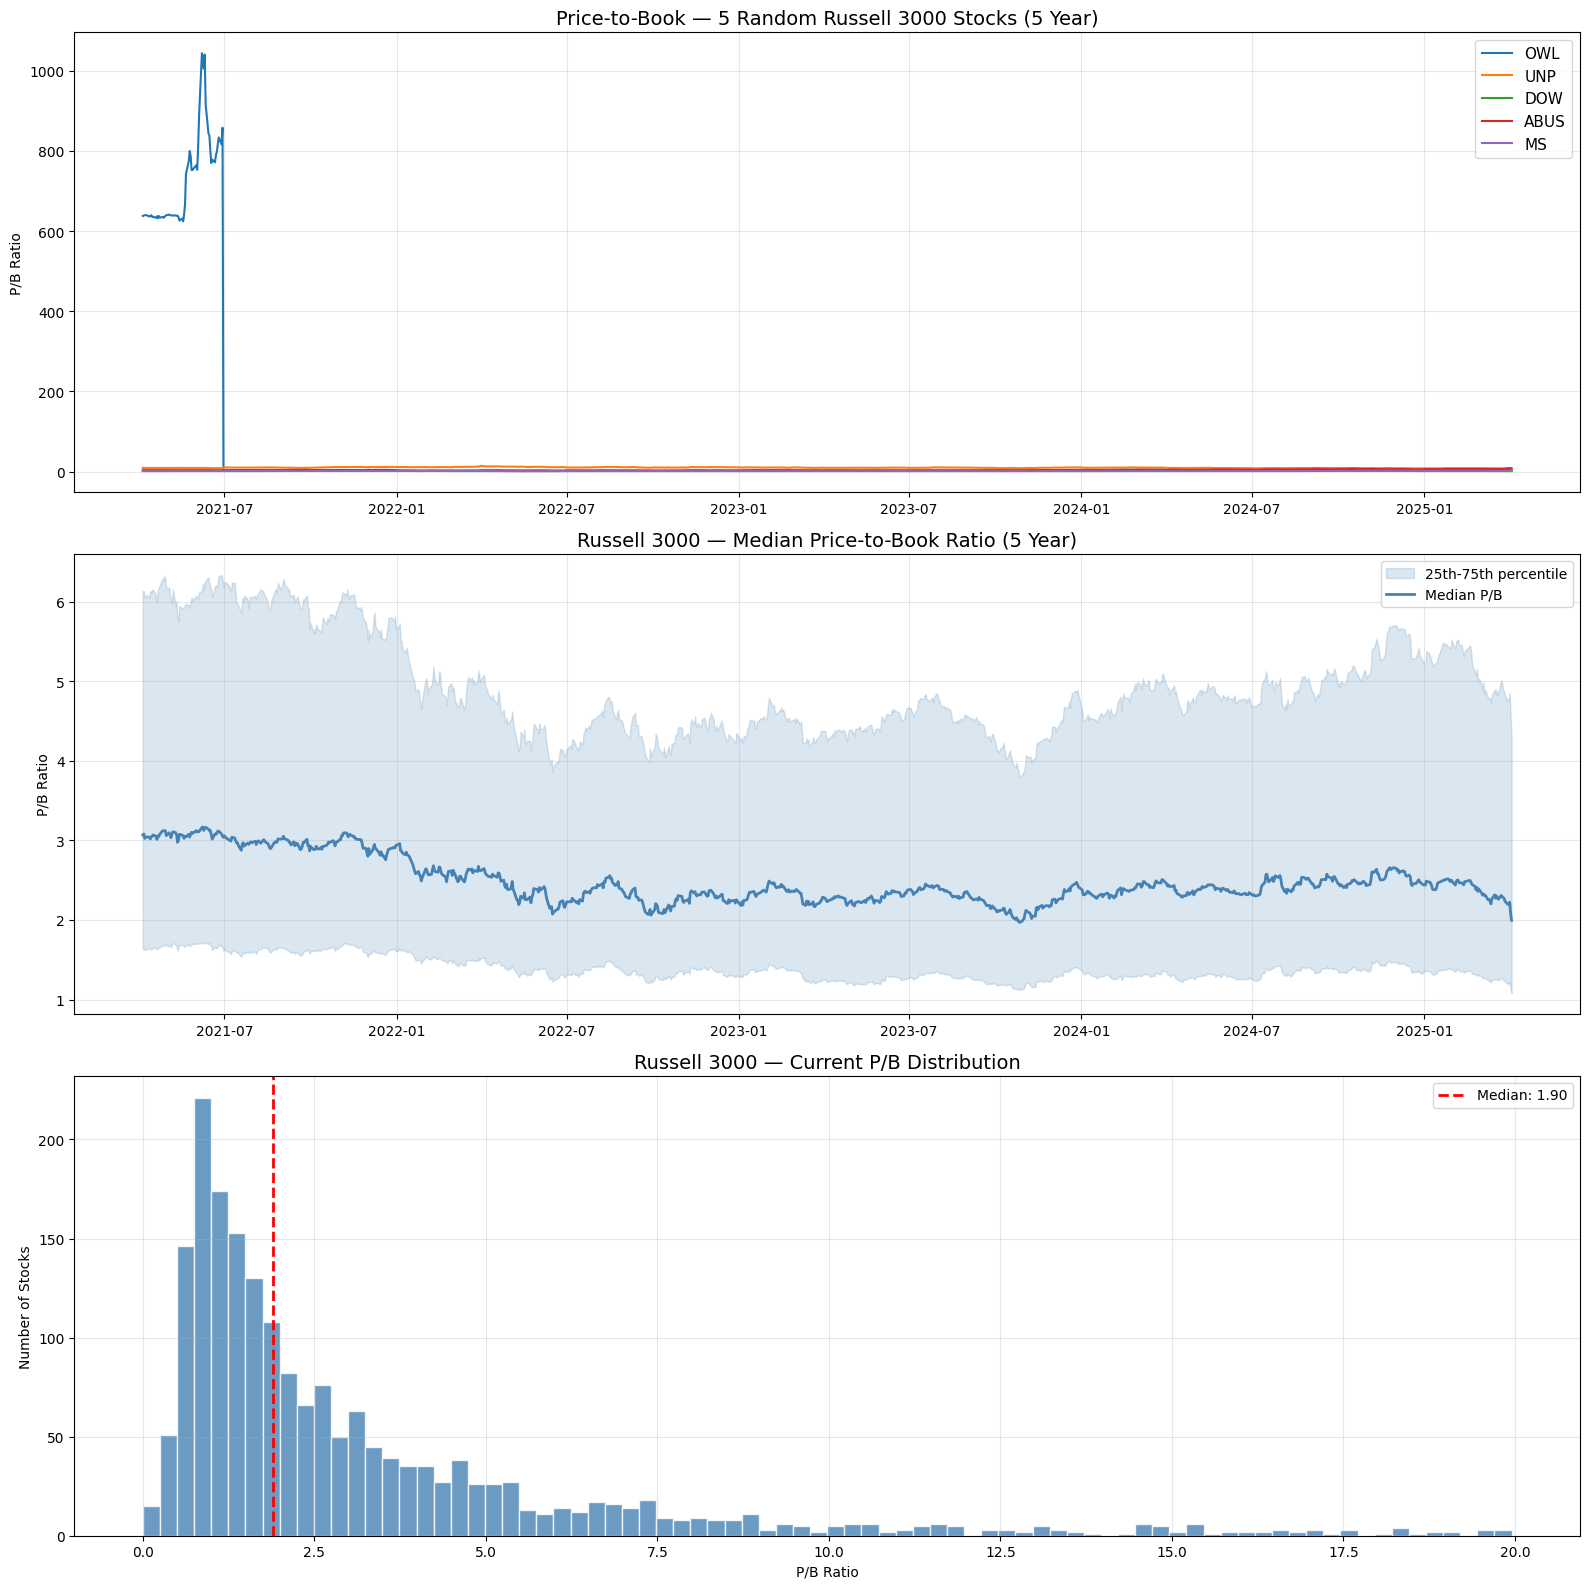


Random tickers shown: ['OWL', 'UNP', 'DOW', 'ABUS', 'MS']

Summary Stats (current P/B):
count       1998.00
mean        1235.88
std        45393.42
min            0.00
25%            1.08
50%            2.00
75%            4.29
max      1970335.08
Name: 2025-04-04 00:00:00, dtype: float64


In [90]:
# --- Plot Price-to-Book Ratios ---

# Pick 5 random tickers that have data
valid_tickers = pb_df.columns[pb_df.notna().sum() > 50].tolist()
sample_tickers = random.sample(valid_tickers, min(5, len(valid_tickers)))

fig, axes = plt.subplots(3, 1, figsize=(16, 16))

# Plot 1: 5 random individual tickers
ax1 = axes[0]
for t in sample_tickers:
    ax1.plot(pb_df.index, pb_df[t], linewidth=1.5, label=t)
ax1.set_title("Price-to-Book — 5 Random Russell 3000 Stocks (5 Year)", fontsize=14)
ax1.set_ylabel("P/B Ratio")
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Median P/B with interquartile range
ax2 = axes[1]
median_pb = pb_df.median(axis=1)
q25_pb = pb_df.quantile(0.25, axis=1)
q75_pb = pb_df.quantile(0.75, axis=1)
ax2.fill_between(median_pb.index, q25_pb, q75_pb, alpha=0.2, color="steelblue", label="25th-75th percentile")
ax2.plot(median_pb.index, median_pb, color="steelblue", linewidth=2, label="Median P/B")
ax2.set_title("Russell 3000 — Median Price-to-Book Ratio (5 Year)", fontsize=14)
ax2.set_ylabel("P/B Ratio")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Distribution of current P/B values
ax3 = axes[2]
current_pb = pb_df.iloc[-1].dropna()
current_pb_clipped = current_pb[(current_pb > 0) & (current_pb < 20)]
ax3.hist(current_pb_clipped, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
ax3.axvline(current_pb_clipped.median(), color="red", linestyle="--", linewidth=2, label=f"Median: {current_pb_clipped.median():.2f}")
ax3.set_title("Russell 3000 — Current P/B Distribution", fontsize=14)
ax3.set_xlabel("P/B Ratio")
ax3.set_ylabel("Number of Stocks")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRandom tickers shown: {sample_tickers}")
print(f"\nSummary Stats (current P/B):")
print(current_pb.describe().round(2))

In [91]:
# --- Data Quality Check ---

# Coverage per ticker: % of trading days with non-null P/B
coverage = pb_df.notna().sum() / pb_df.shape[0] * 100

# Buckets
good = coverage[coverage >= 90]
partial = coverage[(coverage >= 50) & (coverage < 90)]
sparse = coverage[(coverage > 0) & (coverage < 50)]
zero = coverage[coverage == 0]

print(f"=== P/B Data Coverage ({pb_df.shape[0]} trading days) ===")
print(f"  Good (>=90%):    {len(good)} tickers")
print(f"  Partial (50-90%): {len(partial)} tickers")
print(f"  Sparse (<50%):   {len(sparse)} tickers")
print(f"  No data (0%):    {len(zero)} tickers")

# What's causing NaNs — is it Market Cap or Equity?
mktcap_coverage = mktcap.notna().sum() / mktcap.shape[0] * 100
equity_coverage = equity_daily.notna().sum() / equity_daily.shape[0] * 100

mktcap_missing = (mktcap_coverage == 0).sum()
equity_missing = (equity_coverage == 0).sum()

print(f"\n=== Root Cause ===")
print(f"  Tickers with NO Market Cap data:  {mktcap_missing}")
print(f"  Tickers with NO Equity data:      {equity_missing}")

# Show tickers with zero data
print(f"\n=== Tickers with 0% P/B coverage ===")
print(zero.index.tolist())

# Show sparse tickers
if len(sparse) > 0:
    print(f"\n=== Sparse tickers (<50% coverage) ===")
    for t in sparse.sort_values().index[:20]:
        mc_pct = mktcap_coverage.get(t, 0)
        eq_pct = equity_coverage.get(t, 0)
        print(f"  {t:6s}: P/B={coverage[t]:.0f}% | MktCap={mc_pct:.0f}% | Equity={eq_pct:.0f}%")

=== P/B Data Coverage (1007 trading days) ===
  Good (>=90%):    1777 tickers
  Partial (50-90%): 142 tickers
  Sparse (<50%):   82 tickers
  No data (0%):    171 tickers

=== Root Cause ===
  Tickers with NO Market Cap data:  51
  Tickers with NO Equity data:      125

=== Tickers with 0% P/B coverage ===
['AAL', 'ADCT', 'ADEA', 'AIP', 'ALNT', 'AMRX', 'APPN', 'AQST', 'ARRY', 'ATEC', 'AVAH', 'AZO', 'BA', 'BAM', 'BATRA', 'BATRK', 'BBAI', 'BBIO', 'BBNX', 'BBWI', 'BCRX', 'BKNG', 'BLND', 'BOC', 'BOX', 'BRBR', 'CAH', 'CAR', 'CATX', 'CCSI', 'CDP', 'CECO', 'CENTA', 'CHH', 'CHRS', 'CLMB', 'CMPR', 'CORZ', 'CPS', 'CYH', 'CYTK', 'DAVE', 'DBI', 'DBX', 'DELL', 'DIN', 'DNTH', 'DOCN', 'DOMO', 'DPZ', 'DSGR', 'DVA', 'ECVT', 'ELVN', 'EMBC', 'EOLS', 'EOSE', 'ESPR', 'ETSY', 'EVGO', 'FICO', 'GCMG', 'GH', 'GIC', 'GRND', 'GSHD', 'GTX', 'HCA', 'HLF', 'HLT', 'HPQ', 'HRB', 'HTZ', 'IBRX', 'IHRT', 'INDV', 'INSE', 'IRM', 'IRON', 'IRWD', 'JACK', 'LAW', 'LILAK', 'LIND', 'LOW', 'LUNR', 'MAMA', 'MAR', 'MAS', 'MATV', '

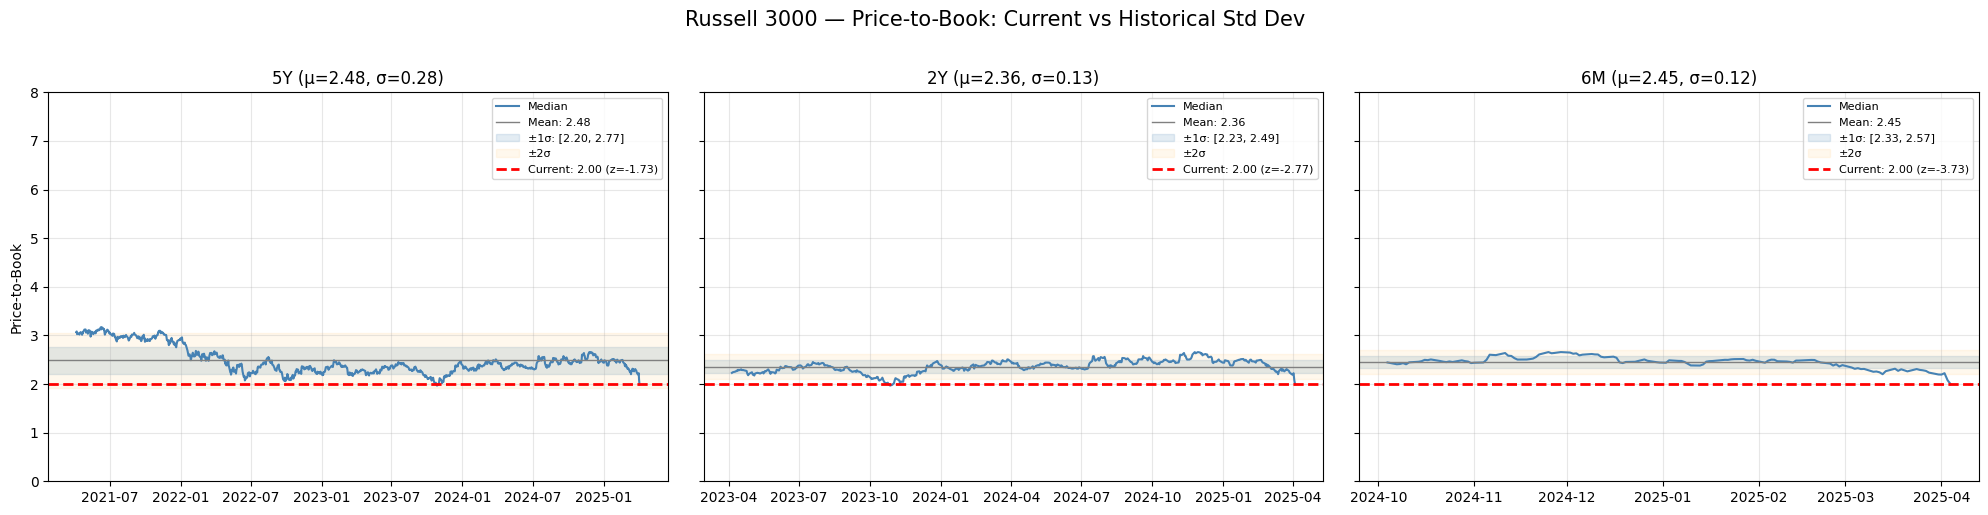

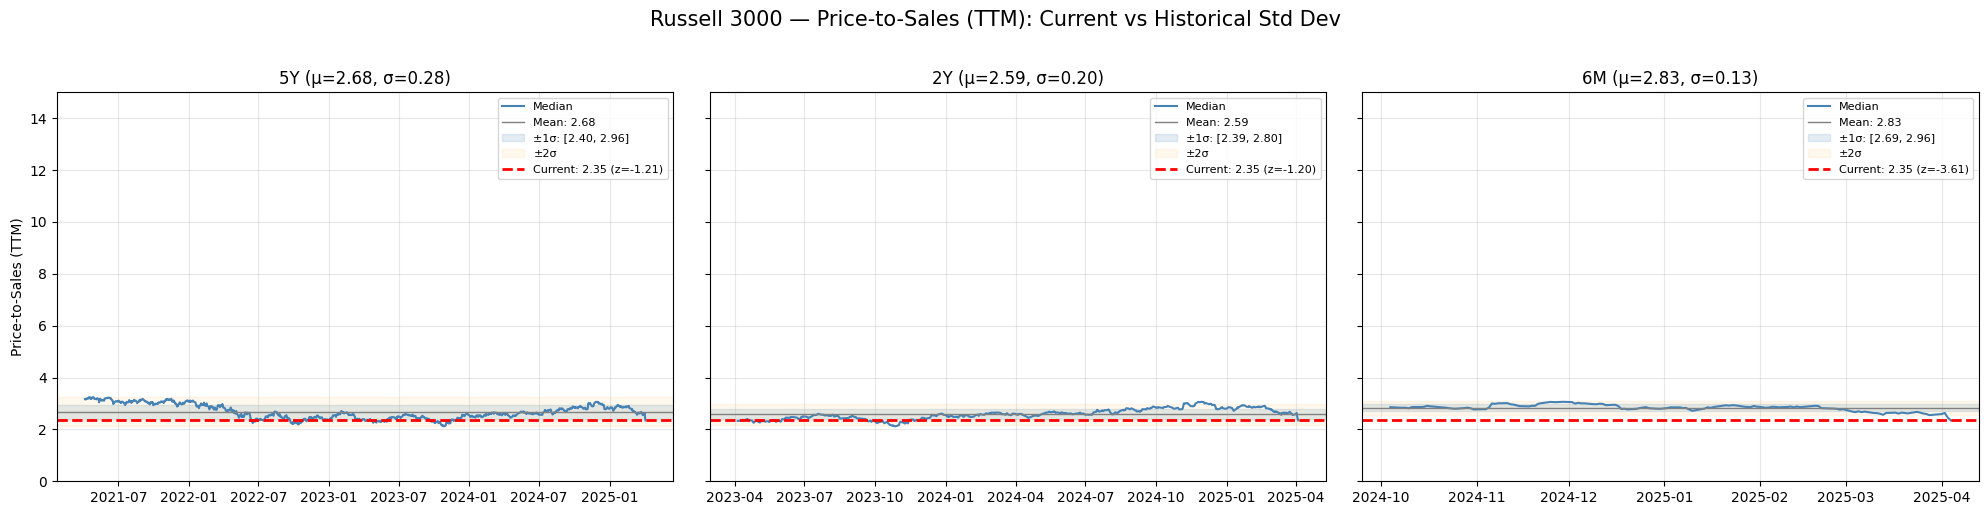

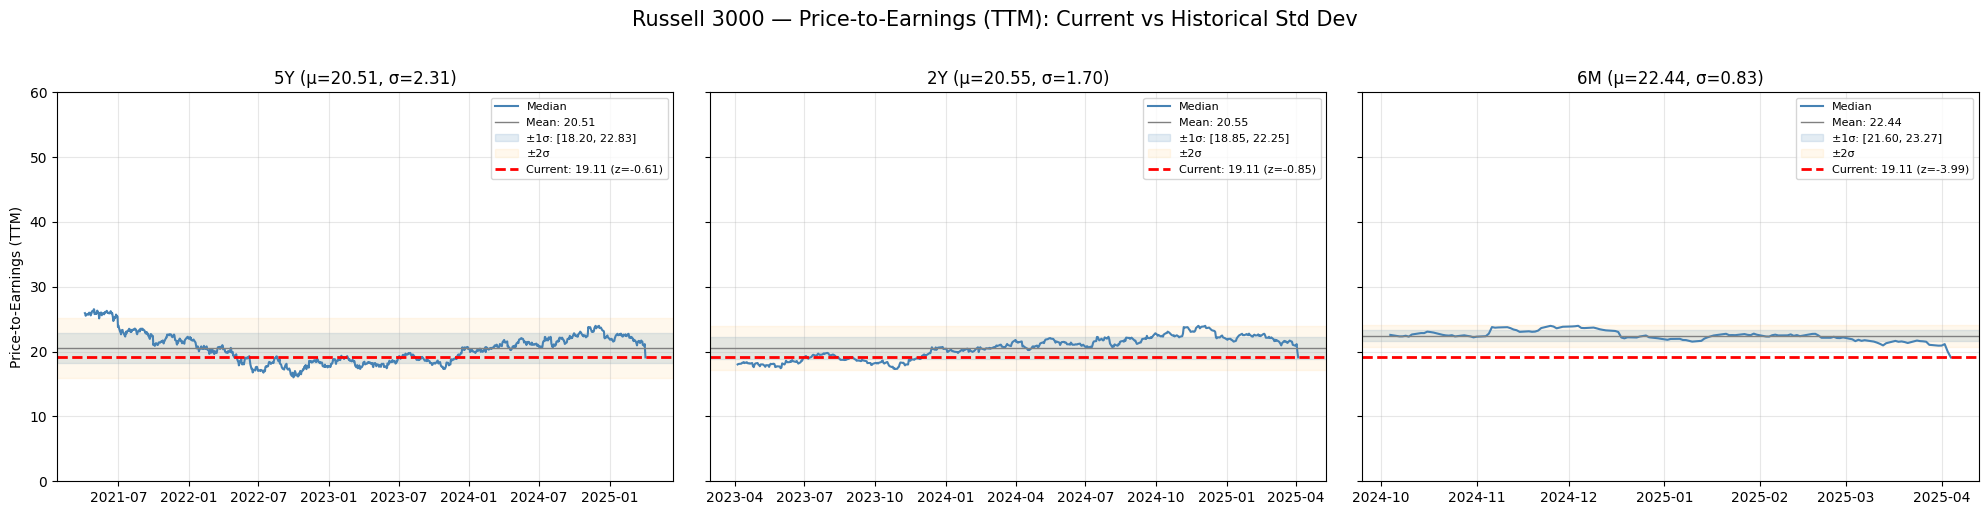

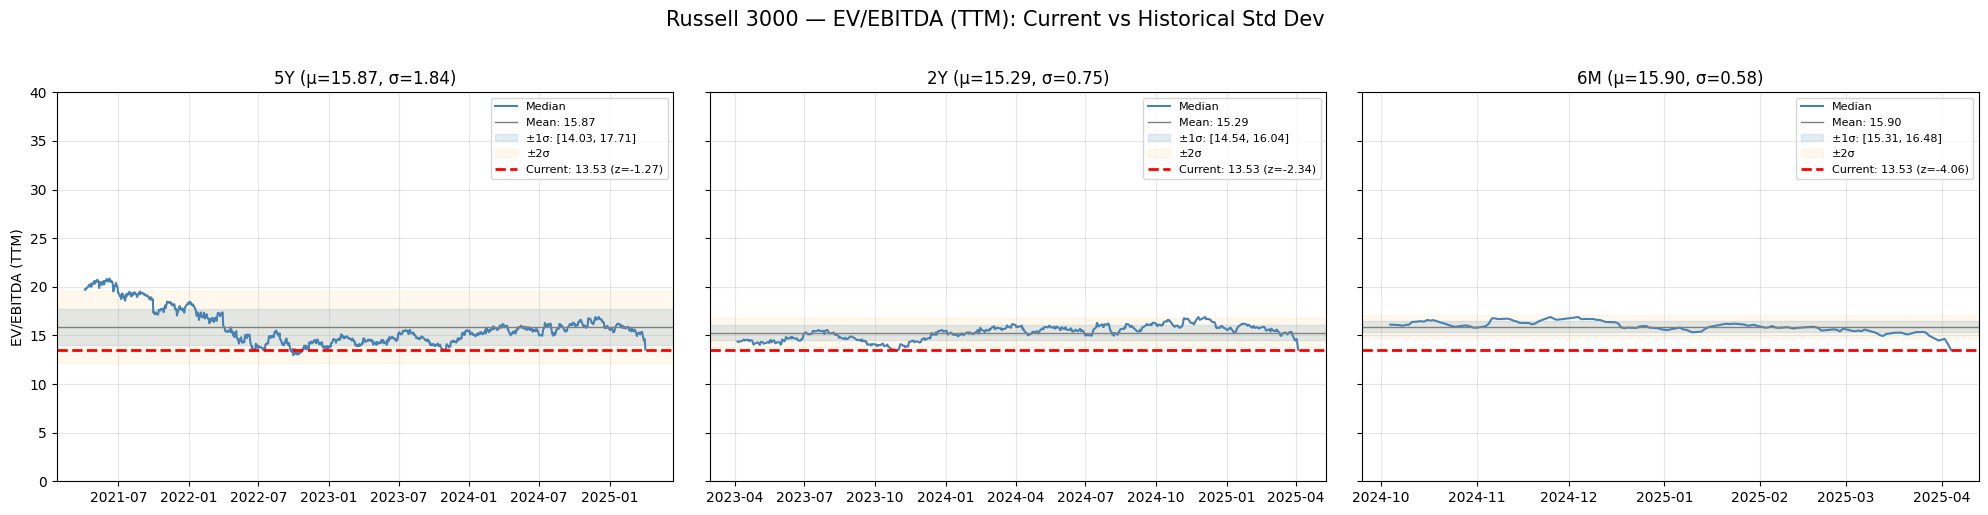

In [92]:
# --- Multi-Horizon: Current Ratio vs Historical Std Dev (5Y / 2Y / 6M) ---
# Each window computes mean & std ONLY from data within that window (no leakage).

now = trading_dates.max()
windows = {
    "5Y": now - timedelta(days=5*365),
    "2Y": now - timedelta(days=2*365),
    "6M": now - timedelta(days=182),
}

ratios = [
    ("Price-to-Book", pb_df, (0, 8)),
    ("Price-to-Sales (TTM)", ps_df, (0, 15)),
    ("Price-to-Earnings (TTM)", pe_df, (0, 60)),
    ("EV/EBITDA (TTM)", ev_ebitda_df, (0, 40)),
]

for ratio_name, full_df, ylim in ratios:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
    fig.suptitle(f"Russell 3000 — {ratio_name}: Current vs Historical Std Dev", fontsize=15, y=1.02)

    for ax, (wname, wstart) in zip(axes, windows.items()):
        # Slice to ONLY this window
        window_df = full_df.loc[full_df.index >= wstart]

        if window_df.empty:
            ax.set_title(f"{wname} — no data")
            continue

        # Cross-sectional median per day (within window only)
        median = window_df.median(axis=1)

        # Stats computed only over this window
        window_mean = median.mean()
        window_std = median.std()
        current_val = median.iloc[-1]

        # Plot median time series
        ax.plot(median.index, median, color="steelblue", linewidth=1.5, label="Median")

        # Mean line
        ax.axhline(window_mean, color="gray", linestyle="-", linewidth=1,
                   label=f"Mean: {window_mean:.2f}")

        # +/- 1 std dev band
        ax.axhspan(window_mean - window_std, window_mean + window_std,
                   alpha=0.15, color="steelblue",
                   label=f"\u00b11\u03c3: [{window_mean - window_std:.2f}, {window_mean + window_std:.2f}]")

        # +/- 2 std dev band
        ax.axhspan(window_mean - 2*window_std, window_mean + 2*window_std,
                   alpha=0.07, color="orange", label=f"\u00b12\u03c3")

        # Current value
        z_score = (current_val - window_mean) / window_std if window_std > 0 else 0
        ax.axhline(current_val, color="red", linestyle="--", linewidth=2,
                   label=f"Current: {current_val:.2f} (z={z_score:+.2f})")

        ax.set_title(f"{wname} (\u03bc={window_mean:.2f}, \u03c3={window_std:.2f})", fontsize=12)
        ax.set_ylim(ylim)
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(ratio_name)
    plt.tight_layout()
    plt.show()
    print()